In [1]:
import pandas as pd
import numpy as np
import re
from wordcloud import WordCloud, STOPWORDS
import spacy
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import time
import joblib
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import mlflow
import json
from sklearn.metrics import ConfusionMatrixDisplay
from lime.lime_text import LimeTextExplainer
from collections import OrderedDict

### **Loading dataset**

In [2]:
# function to load dataset

def load_dataset(dataset_loc:str, num_samples=None):
    df = pd.read_csv(dataset_loc)
    df = df.sample(num_samples, random_state=42) if num_samples else df
    return df


In [3]:
# load dataset

train_df = load_dataset("../datasets/train.csv")
val_df = load_dataset('../datasets/val.csv')

# keeping a copy for exploration
train_copy = train_df.copy()

### **PREPROCESSING**

In [4]:
# using the steps below to clean and normalize data

# Steps:
# 1. lower case
# 2. remove stopwords
# 3. remove punctuations
# 4. remove non-alphanumeric
# 5. collapse repeated scrubbing (eg XXXX XXXX into MASK) 
# 6. remove multiple spaces
# 7. lemmatize

In [5]:
# get some sample data from the train copy
sample_train_data = train_df.sample(10000, random_state=42)

In [6]:
# top 5 examples
sample_train_data.head(5)

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue,labels
5082,Credit reporting or other personal consumer re...,I am disputing an account that was opened and ...,2026-06-18T09:47:42.000Z,Incorrect information on your report,Credit reporting,91732,NaN,23333192,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2026-06-18T09:31:50.000Z,CA,Company has responded to the consumer and the ...,Information belongs to someone else,Credit Reporting & Disputes
7195,Credit card,"b""Hi, i had a car accident a few years ago and...",2026-07-01T18:44:44.000Z,Problem with a purchase shown on your statement,General-purpose credit card or charge card,80524,NaN,23763461,Yes,Closed with explanation,Web,"CITIBANK, N.A.",2026-07-01T18:39:57.000Z,CO,Company has responded to the consumer and the ...,Card was charged for something you did not pur...,Cards & Payments
10280,Debt collection,"To the Consumer Financial Protection Bureau, I...",2026-05-25T17:39:07.000Z,Written notification about debt,Credit card debt,11207,NaN,22540521,Yes,Closed with explanation,Web,ENCORE CAPITAL GROUP INC.,2026-05-25T17:10:14.000Z,NY,NaN,Didn't receive enough information to verify debt,Collections & Recovery
10126,Debt collection,b'I am filing this complaint against XXXX XXXX...,2026-07-01T19:49:06.000Z,Attempts to collect debt not owed,Payday loan debt,91360,NaN,23766739,Yes,Closed with explanation,Web,"CreditNinja Lending, LLC",2026-07-01T19:48:40.000Z,CA,Company has responded to the consumer and the ...,Debt is not yours,Collections & Recovery
9688,Debt collection,I was contacted via text and email regarding d...,2026-05-13T22:19:16.000Z,Attempts to collect debt not owed,I do not know,85138,"Older American, Servicemember",22178506,Yes,Closed with explanation,Web,TrueAccord Corp.,2026-05-13T22:11:00.000Z,AZ,NaN,Debt is not yours,Collections & Recovery


In [7]:
# using spacy's model to get stop words

nlp = spacy.load("en_core_web_sm", enable=["tok2vec",'lemmatizer', 'tagger', 'attribute_ruler'])
stopwords = nlp.Defaults.stop_words
stopwords = set(stopwords)

In [8]:
def clean_text(text, stopwords=stopwords):
    text = text.lower()
    text = " ".join([token for token in text.split() if token not in stopwords]) # removing stop words
    text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text) #removing punctuations
    text = re.sub("[^A-Za-z]+", " ", text) # remove non-alphanumeric characters
    pattern = re.compile(r"(xx+\s*)+") # remove repeated XXXX characters
    text = pattern.sub(" mask ", text) # rename repeated XXXX characters to mask
    text = re.sub(" +", " ", text).strip() # remove repeated spaces
    text = re.sub(r"http\S+", "", text) # remove hyperlinks
    return text

In [9]:
# apply the clean_text function to clean text

sample_train_data['cleaned_text'] = sample_train_data['complaint_what_happened'].apply(clean_text)

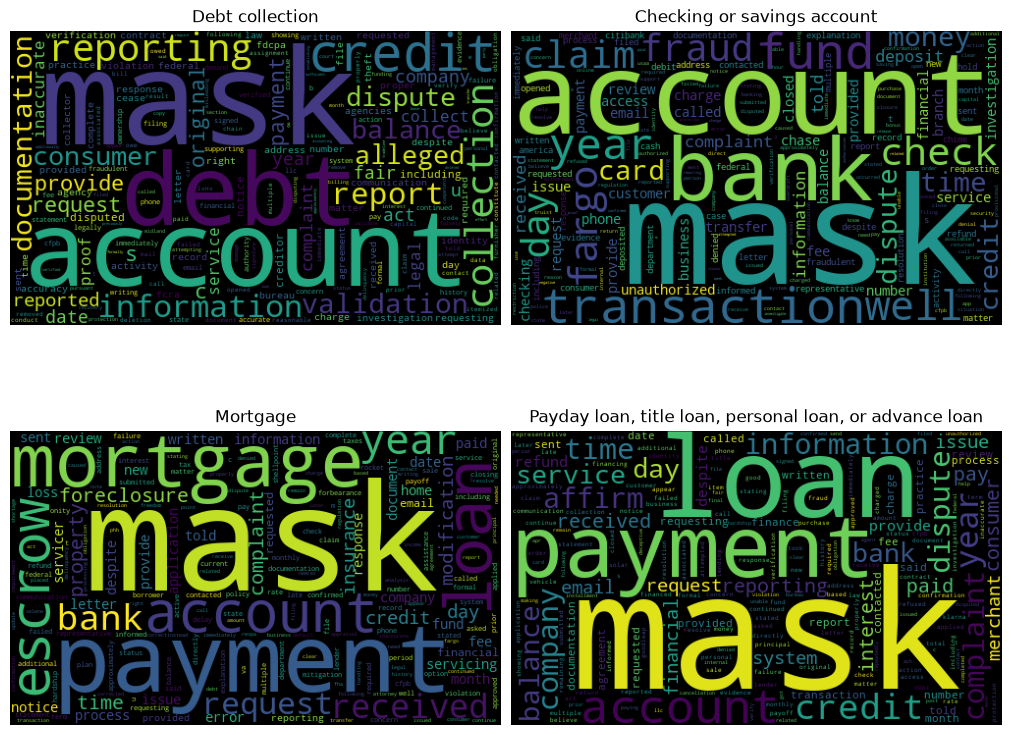

In [10]:
# plot wordcloud to see which words appear most

def plot_cleaned_words(ax, target, df):
    selected_text_for_product = df[df['product']==target]['cleaned_text'].to_list()
    
    wordcloud = WordCloud(stopwords=STOPWORDS, 
            background_color="black", 
            collocations=False, 
            width=500, 
            height=300).generate(" ".join(selected_text_for_product))
    
    ax.axis("off")
    ax.set_title(target)
    ax.imshow(wordcloud)

fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(2, 2, figsize=(10, 8), layout='constrained')
plot_cleaned_words(ax0, "Debt collection", df=sample_train_data)
plot_cleaned_words(ax1, "Checking or savings account", df=sample_train_data)
plot_cleaned_words(ax2, "Mortgage", df=sample_train_data)
plot_cleaned_words(ax3, "Payday loan, title loan, personal loan, or advance loan", df=sample_train_data)

In [11]:
# apply to train_copy dataset
# get length of text after cleaning to filter short texts.

train_copy['cleaned_text'] = train_copy['complaint_what_happened'].apply(clean_text)

train_copy['text_length'] = train_copy['cleaned_text'].apply(lambda x: len(x.split()))
train_copy.head(1)

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue,labels,cleaned_text,text_length
0,Checking or savings account,This account is not mine. I requested verifica...,2026-06-10T15:34:29.000Z,Opening an account,Checking account,30144,NaN,23072671,Yes,Closed with explanation,Web,"Fidelity National Information Services, Inc. (...",2026-06-10T15:17:21.000Z,GA,Company has responded to the consumer and the ...,Account opened without my consent or knowledge,Banking Operations,account mine requested verification documents ...,31


In [12]:
# distribution of text length
train_copy['text_length'].describe()

count    14198.000000
mean       126.684744
std        137.497945
min          1.000000
25%         48.000000
50%         95.000000
75%        161.000000
max       2937.000000
Name: text_length, dtype: float64

In [13]:
# filter short sentences. sentences==1 or less than 5
train_copy[train_copy['text_length']==1][["complaint_what_happened", "cleaned_text", "text_length", "labels"]]

,complaint_what_happened,cleaned_text,text_length,labels
8328,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,mask,1,Credit Reporting & Disputes
9182,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,mask,1,Banking Operations
10745,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,mask,1,Collections & Recovery
12642,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,mask,1,Banking Operations


In [14]:
# cleaned text length will be limited to minimum of 4 words

equal_or_less_than_three = train_copy['text_length']<=3
train_copy[equal_or_less_than_three][["complaint_what_happened", "cleaned_text", "text_length", "labels"]]

,complaint_what_happened,cleaned_text,text_length,labels
116,Threatening me about debt I have no knowledge ...,threatening debt knowledge,3,Collections & Recovery
6174,I havent used my Creidt and theres so much on ...,havent creidt theres,3,Collections & Recovery
6884,Nothing was done some were paid off and are no...,paid credit paid,3,Collections & Recovery
8328,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,mask,1,Credit Reporting & Disputes
9182,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,mask,1,Banking Operations
10745,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,mask,1,Collections & Recovery
12218,This was included in my bankruptcy and its sti...,included bankruptcy reported,3,Collections & Recovery
12642,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,mask,1,Banking Operations
13426,b'XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX...,b mask,2,Credit Reporting & Disputes


In [15]:
# filtered train dataset
train_copy = train_copy[~equal_or_less_than_three][["complaint_what_happened", "cleaned_text", "labels"]]
train_copy.head(3)

,complaint_what_happened,cleaned_text,labels
0,This account is not mine. I requested verifica...,account mine requested verification documents ...,Banking Operations
1,I am writing to file a formal complaint regard...,writing file formal complaint federal student ...,Consumer Lending
2,I financed a furniture purchase through XXXX X...,financed furniture purchase mask synchrony mas...,Cards & Payments


In [16]:
# Map Labels to Index for later training
class_to_idx = {label:idx for idx, label in enumerate(sorted(train_copy['labels'].unique()))}
train_copy['labels'] = train_copy['labels'].map(class_to_idx)
train_copy.head(3)

,complaint_what_happened,cleaned_text,labels
0,This account is not mine. I requested verifica...,account mine requested verification documents ...,0
1,I am writing to file a formal complaint regard...,writing file formal complaint federal student ...,3
2,I financed a furniture purchase through XXXX X...,financed furniture purchase mask synchrony mas...,1


In [17]:
idx_to_class = {value:key for key, value in class_to_idx.items()}
def decode(indices, idx_to_class):
    return [idx_to_class[idx] for idx in indices]

# test function
sample_labels = train_copy[:5]['labels'].values
decode(sample_labels, idx_to_class)

['Banking Operations',
 'Consumer Lending',
 'Cards & Payments',
 'Banking Operations',
 'Collections & Recovery']

# **MODELLING: LOGISTIC REGRESSION + TD-IDF**

### **Functions to apply to different datasets eg train, val, inference sets**

In [18]:
#lemmatize the text to get the root of each word

def lemmatize_text(df: pd.DataFrame)->list:
    all_complaints = df['complaint_what_happened'].tolist()
    complaints_docs = nlp.pipe(all_complaints, batch_size=128, n_process=-1)

    lemmatized_sentences = []
    for doc in tqdm(complaints_docs, desc="Lemmatizing.."):
        lemmatized_sentences.append(" ".join([token.lemma_ for token in doc]))

    return lemmatized_sentences

In [19]:
# this function cleans the complaint text
  
def preprocess_dataset(dataframe: pd.DataFrame, class_to_idx: dict):
    df = dataframe.copy()
    tqdm.pandas(desc="Processing texts", colour='green')
    
    df['text'] = df.text.progress_apply(clean_text)
    if 'labels' in df.columns:
        df['labels'] = df.labels.map(class_to_idx)
        return df[["product", "complaint_what_happened", "text", "labels"]]
    else:
        return df[["complaint_what_happened", "text"]]

In [20]:
# Uses the preprocess_dataset function 

class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, df):
        tags = sorted(df['labels'].unique())
        self.class_to_idx = {label:idx for idx, label in enumerate(tags)}
        self.idx_to_class = {value:key for key, value in self.class_to_idx.items()}
        return self

    def transform(self, df, y=None):
        return preprocess_dataset(df, class_to_idx=self.class_to_idx)

### **Trainer model class**

In [21]:
class TFIDFTrainer:
    def __init__(
            self, 
            model: LogisticRegression, 
            preprocessor:CustomPreprocessor, 
            vectorizer:TfidfVectorizer, 
            directory:str,
            train_dataset:pd.DataFrame,
            val_dataset:pd.DataFrame=None,
            experiment_name=None,
            log_experiment:bool=False,
            params=None,

            ):
        if params==None:
            self.params = None
            self.model = model()
        else:
            self.params = params
            self.model = model(**self.params) # i will save this

        self.preprocessor = preprocessor # i will save this
        self.vectorizer = vectorizer # i will save this
        self.directory_name = directory # path i will use to save above
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.experiment_name = experiment_name
        self.log_experiment = log_experiment

    def preprocess(self):
        dataset = self.preprocessor.fit_transform(self.train_dataset)
        dataset['text_length'] = dataset.text.apply(lambda x: len(x.split()))
        short_complaints = dataset['text_length']<=3
        return dataset[~short_complaints]

    def save_artifacts(self, preprocessor, vectorizer, model):
        artifacts = {"model": model, "preprocessor": preprocessor, "vectorizer": vectorizer}
        artifacts_path = Path().cwd().parent / self.directory_name
        if not artifacts_path.exists():
            artifacts_path.mkdir(parents=True)
        joblib.dump(artifacts, artifacts_path / "artifacts.joblib")

    def mlflow_logging(self, train_vectors, train_labels):
        mlflow.set_tracking_uri("http://127.0.0.1:5000")
        mlflow.set_experiment(self.experiment_name)
        
        with mlflow.start_run():
            self.model.fit(train_vectors, train_labels)
            y_train_pred = self.model.predict(train_vectors)

            val_dataset_processed = self.preprocessor.transform(self.val_dataset)
            val_vectors = self.vectorizer.transform(val_dataset_processed.text).toarray()
            y_val_pred = self.model.predict(val_vectors)
            val_labels = val_dataset_processed.labels

            for name, y_true, y_pred in [("train", train_labels, y_train_pred), ("val", val_labels, y_val_pred)]:

                metrics = precision_recall_fscore_support(y_true=y_true, y_pred=y_pred, average='macro')
                mlflow.log_metrics({f"acc_{name}": accuracy_score(y_true=y_true, y_pred=y_pred), 
                                    f"prec_macro_{name}": metrics[0],
                                    f"recall_macro_{name}": metrics[1],
                                    f"f1_macro_{name}": metrics[2],
                                    f"weighted_f1_{name}": f1_score(y_true=y_true, y_pred=y_pred, average='weighted')
                                    })
            if self.params != None:
                mlflow.log_params(self.params)

    def train(self):
        start = time.time()
        preprocessed_dataset = self.preprocess()
        print(f"Train Examples: {preprocessed_dataset.shape[0]}")
        labels = preprocessed_dataset.labels
        train_vectors = self.vectorizer.fit_transform(preprocessed_dataset['text']).toarray()

        if self.log_experiment:
            print(f"Training and Logging to MLFLOW experiment {self.experiment_name}...")
            self.mlflow_logging(train_vectors=train_vectors, train_labels=labels)
        else:
            print("Training...")
            self.model.fit(train_vectors, labels)
        
        self.save_artifacts(preprocessor=self.preprocessor, vectorizer=self.vectorizer, model=self.model)
        end = time.time()
        total_time = end-start
        print(f"Total training time {total_time:.2f} secs")
        return self.model

In [22]:
# lemmatize text and later train model using lemmatized dataset

train_df['text'] = lemmatize_text(train_df)
val_df['text'] = lemmatize_text(val_df)

train_df_copied = train_df.copy()
val_df_copied = val_df.copy()

Lemmatizing..: 14198it [06:02, 39.21it/s] 
Lemmatizing..: 3550it [02:01, 29.16it/s] 


In [23]:
trainer = TFIDFTrainer(
                  model=LogisticRegression, 
                  preprocessor=CustomPreprocessor(), 
                  vectorizer=TfidfVectorizer(stop_words="english", 
                                              max_features=5000, 
                                              ngram_range=(1,3)),
                  train_dataset=train_df_copied,
                  val_dataset=val_df_copied,
                  directory="models",
                  params={"random_state":42, "max_iter":1000},
                  log_experiment=False,
                  experiment_name="textclf_logistic",
                  )

# train model
trainer.train()

Processing texts: 100%|██████████| 14198/14198 [00:08<00:00, 1590.18it/s]


Train Examples: 14183
Training...
Total training time 54.95 secs


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

# **HELPER FUNCTIONS**

#### **Predictor class that loads the best checkpoint using a saved directory path**

In [24]:
class TFIDFPredictor:
    def __init__(self, preprocessor, vectorizer, model):
        self.preprocessor = preprocessor
        self.vectorizer = vectorizer
        self.model = model

    @classmethod
    def from_checkpoint(cls, checkpoint: str):
        artifacts = joblib.load(checkpoint)
        preprocessor = artifacts['preprocessor']
        vectorizer = artifacts['vectorizer']
        model = artifacts['model']
        return cls(preprocessor, vectorizer, model)

    def __call__(self, dataset:pd.DataFrame):
        cleaned_dataset = self.preprocessor.transform(dataset)
        vectors = self.vectorizer.transform(cleaned_dataset.text).toarray()
        return self.model.predict(vectors)

#### **Function to evaluate model**

In [25]:
def evaluate_df_with_labels(df, predictor):
    df_copy = df.copy()
    df_with_labels = predictor.preprocessor.transform(df_copy)
    y_true = df_with_labels['labels']

    y_pred = predictor(df)
    accuracy = accuracy_score(y_true=y_true, y_pred=y_pred)
    weighted_f1 = f1_score(y_true=y_true, y_pred=y_pred, average='weighted')
    metrics = precision_recall_fscore_support(y_true=y_true, y_pred=y_pred, average='macro')

    print(f"{classification_report(y_true=y_true, y_pred=y_pred)}\n")
    metrics = {"accuracy": accuracy, 
               "precision_macro": metrics[0],
               "recall_macro": metrics[1],
               "f1_macro":metrics[2],
               "weighted_f1":weighted_f1
               }
        
    return metrics

In [26]:
# testing function
checkpoint = Path().cwd().parent / "models/artifacts.joblib"
predictor = TFIDFPredictor.from_checkpoint(checkpoint)
val_df_copy_copy = val_df.copy()
evaluate_df_with_labels(val_df_copy_copy, predictor)

Processing texts: 100%|██████████| 3550/3550 [00:02<00:00, 1372.57it/s]


              precision    recall  f1-score   support

           0       0.78      0.85      0.81       754
           1       0.82      0.84      0.83       754
           2       0.88      0.91      0.90       962
           3       0.83      0.79      0.81       423
           4       0.80      0.64      0.71       110
           5       0.75      0.65      0.69       280
           6       0.97      0.84      0.90       267

    accuracy                           0.83      3550
   macro avg       0.83      0.79      0.81      3550
weighted avg       0.84      0.83      0.83      3550




{'accuracy': 0.8346478873239437,
 'precision_macro': 0.8336530848047446,
 'recall_macro': 0.7883438349834414,
 'f1_macro': 0.8081514744643693,
 'weighted_f1': 0.8336757538457182}

#### **Function to predict the probabilities of a prediction**

In [27]:
# predict proba
def predict_with_proba(df, predictor):
    preprocessor = predictor.preprocessor
    vectorizer = predictor.vectorizer
    model = predictor.model

    df_transformed = preprocessor.transform(df)
    df_vectorized = vectorizer.transform(df_transformed.text).toarray()
    predicted_probas = model.predict_proba(df_vectorized)

    labels = [key for key in preprocessor.class_to_idx]
    
    all_pred_with_proba = []
    for score in predicted_probas:
        pred = int(score.argmax())
        all_pred_with_proba.append({
            "prediction":labels[pred],
            "probabilities":{a:round(float(b), 4) for a, b in zip(labels, score)}
            })

    return all_pred_with_proba

In [28]:
complaint = "I need to pay my debt but I do not like you keep heckling me. I understand you guys need to collect my debt"
sent_lemma = " ".join([token.lemma_ for token in nlp(complaint)])
df = pd.DataFrame({"complaint_what_happened":[complaint], "text":[sent_lemma]})
predict_with_proba(df, predictor)

Processing texts: 100%|██████████| 1/1 [00:00<?, ?it/s]


[{'prediction': 'Collections & Recovery',
  'probabilities': {'Banking Operations': 0.0067,
   'Cards & Payments': 0.008,
   'Collections & Recovery': 0.9576,
   'Consumer Lending': 0.0144,
   'Credit Reporting & Disputes': 0.0045,
   'Money Transfer and Payments': 0.0046,
   'Mortgage & Home Lending': 0.0042}}]

# **EVALUATION OF LOGISTIC REG + TD-IDF**


In [29]:
# evaluation on val set first
val_df_evaluate = val_df[["product", "complaint_what_happened", "labels", "text"]].copy()
val_df_evaluate = predictor.preprocessor.transform(val_df_evaluate)
val_df_evaluate_vecs = predictor.vectorizer.transform(val_df_evaluate.text).toarray()

# predict
val_predictions = predictor.model.predict(val_df_evaluate_vecs)
y_probs = predictor.model.predict_proba(val_df_evaluate_vecs)

# add predictions to df
pred_labels = [predictor.preprocessor.idx_to_class[pred] for pred in val_predictions]
val_df_evaluate['prediction'] = pred_labels

val_true = val_df_evaluate['labels'] # get true labels for val
val_df_evaluate['labels'] = val_df_evaluate['labels'].map(predictor.preprocessor.idx_to_class)

Processing texts: 100%|██████████| 3550/3550 [00:02<00:00, 1605.41it/s]


In [30]:
# check predictions

val_df_evaluate.head()

,product,complaint_what_happened,text,labels,prediction
0,Credit card,Bank of America send me a XXXX099D to my perso...,bank america send mask d personal close person...,Cards & Payments,Banking Operations
1,Debt collection,MIDLAND CRED is falsely reporting on my credit...,midland cred falsely report credit account res...,Collections & Recovery,Collections & Recovery
2,Credit card,CONSUMER FINANCIAL PROTECTION BUREAU Official ...,consumer financial protection bureau official ...,Cards & Payments,Cards & Payments
3,Credit card,In XX/XX/XXXX I purchased a couch from XXXX XX...,mask purchase couch mask pay couch order mask ...,Cards & Payments,Collections & Recovery
4,Credit card,"Between XX/XX/XXXX and XX/XX/XXXX, multiple Ap...",mask multiple apple card transaction occur doc...,Cards & Payments,Cards & Payments


In [31]:
# for evaluation 
metrics = {"overall":{}, "class":{}}

In [32]:
# overall metrics

overall_metrics = precision_recall_fscore_support(y_true=val_true, y_pred=val_predictions, average='macro')
metrics['overall']['precision_macro'] = overall_metrics[0]
metrics['overall']['recall_macro'] = overall_metrics[1]
metrics['overall']['f1_macro'] = overall_metrics[2]
metrics['overall']['num_samples'] = np.float64(len(val_true))
print(json.dumps(metrics['overall'], indent=4))

{
    "precision_macro": 0.8336530848047446,
    "recall_macro": 0.7883438349834414,
    "f1_macro": 0.8081514744643693,
    "num_samples": 3550.0
}


In [33]:
# per class metrics
per_class_metrics = precision_recall_fscore_support(y_true=val_true, y_pred=val_predictions, average=None)
for idx, class_ in enumerate(predictor.preprocessor.class_to_idx):
    metrics['class'][class_] = {"precision":per_class_metrics[0][idx],
                                "recall":per_class_metrics[1][idx],
                                "f1":per_class_metrics[2][idx],
                                "num_samples":np.float64(per_class_metrics[3][idx])
                                }  

In [34]:
# check metrics for a category/department
tag = "Mortgage & Home Lending"
print(json.dumps(metrics['class'][tag], indent=4))

{
    "precision": 0.9739130434782609,
    "recall": 0.8389513108614233,
    "f1": 0.9014084507042254,
    "num_samples": 267.0
}


In [ ]:
# order by f1 score
sorted_scores = OrderedDict(sorted(metrics['class'].items(), key=lambda x: x[1]['f1'], reverse=True))
for score_ in sorted_scores:
    print(json.dumps(score_, indent=2)) 

[
  "Mortgage & Home Lending",
  {
    "precision": 0.9739130434782609,
    "recall": 0.8389513108614233,
    "f1": 0.9014084507042254,
    "num_samples": 267.0
  }
]
[
  "Collections & Recovery",
  {
    "precision": 0.880641925777332,
    "recall": 0.9126819126819127,
    "f1": 0.8963757018887187,
    "num_samples": 962.0
  }
]
[
  "Cards & Payments",
  {
    "precision": 0.8246753246753247,
    "recall": 0.8421750663129973,
    "f1": 0.8333333333333334,
    "num_samples": 754.0
  }
]
[
  "Banking Operations",
  {
    "precision": 0.7802197802197802,
    "recall": 0.8474801061007957,
    "f1": 0.8124602670057216,
    "num_samples": 754.0
  }
]
[
  "Consumer Lending",
  {
    "precision": 0.8296296296296296,
    "recall": 0.7943262411347518,
    "f1": 0.8115942028985508,
    "num_samples": 423.0
  }
]
[
  "Credit Reporting & Disputes",
  {
    "precision": 0.7954545454545454,
    "recall": 0.6363636363636364,
    "f1": 0.7070707070707071,
    "num_samples": 110.0
  }
]
[
  "Money Tran

In [35]:
# CONFUSION MATRIX
tag = 'Mortgage & Home Lending'
index = predictor.preprocessor.class_to_idx[tag]
tp, fp, fn = [], [], []

for i, true in enumerate(val_true):
    pred = val_predictions[i]
    if index==pred==true:
        tp.append(i) 
    elif index!=true and index==pred:
        fp.append(i)
    elif index==true and index!=pred:
        fn.append(i)   

In [36]:
print(tp)
print(fp)
print(fn)

[50, 80, 82, 96, 107, 108, 109, 121, 133, 137, 169, 189, 191, 200, 217, 221, 244, 284, 295, 310, 322, 323, 366, 376, 411, 443, 448, 472, 484, 506, 508, 509, 517, 522, 550, 564, 570, 619, 620, 625, 633, 724, 727, 740, 745, 747, 748, 764, 818, 836, 841, 850, 855, 879, 880, 881, 900, 902, 922, 964, 976, 980, 982, 990, 1019, 1022, 1026, 1038, 1042, 1047, 1070, 1112, 1128, 1159, 1163, 1184, 1185, 1207, 1229, 1232, 1270, 1282, 1295, 1331, 1333, 1346, 1355, 1369, 1405, 1409, 1435, 1440, 1443, 1483, 1504, 1529, 1539, 1577, 1591, 1639, 1647, 1672, 1674, 1692, 1729, 1742, 1765, 1789, 1796, 1802, 1807, 1847, 1856, 1870, 1883, 1924, 1925, 1963, 1979, 2000, 2004, 2007, 2009, 2024, 2033, 2047, 2059, 2061, 2067, 2075, 2085, 2128, 2136, 2149, 2222, 2225, 2237, 2238, 2243, 2264, 2274, 2277, 2283, 2295, 2336, 2342, 2349, 2350, 2361, 2367, 2368, 2377, 2409, 2455, 2459, 2475, 2483, 2485, 2491, 2507, 2515, 2528, 2534, 2536, 2565, 2580, 2600, 2629, 2635, 2661, 2665, 2667, 2687, 2697, 2715, 2716, 2794, 2812,

In [37]:
cm = [(tp, "True Positives"), (fp, "False Positives"), (fn, "False Negatives")]
num_samples = 3
for item in cm:
    if len(item[0]):
        print(f"\n=== {item[1]} ===")
        for index in item[0][:num_samples]:
            print(f"{val_df_evaluate.iloc[index].complaint_what_happened}")
            print(f"\t true:{val_df_evaluate.labels[index]}")
            print(f"\t pred:{val_df_evaluate.prediction[index]}\n")


=== True Positives ===
I contacted XXXX multiple times seeking information about how my payment would be applied and was ultimately transferred to XXXX in the Servicing Executive Office. 

Rather than attempting to assist me, XXXX repeatedly refused to provide the requested information, refused to escalate the matter, and refused to consult with anyone else regarding my concerns. Throughout the conversation, she was dismissive and unhelpful. I was left with the clear impression that my concerns were not being taken seriously and that no effort was being made to resolve the issue. 

I explained that I require a breakdown of principal, interest, and escrow in order to maintain accurate accounting records. XXXX informed me that XXXX would not provide that information until after the payment was processed and that I would have to obtain it days later. When I explained why this was a problem and requested assistance in finding a solution, she simply reiterated that XXXX would not provide t

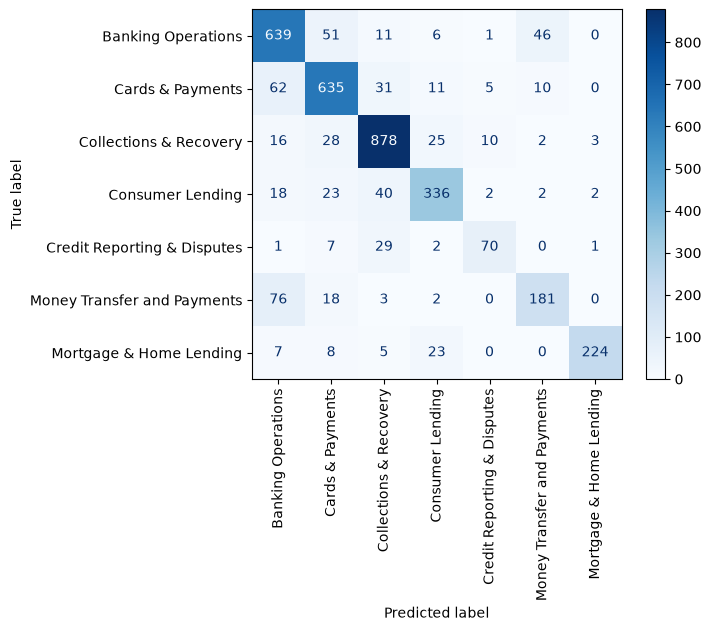

<Figure size 800x800 with 0 Axes>

In [38]:
idx_cm = [x for x in predictor.preprocessor.idx_to_class]
labels_cm = [x for x in predictor.preprocessor.class_to_idx]
cm = confusion_matrix(y_true=val_true, y_pred=val_predictions, labels=idx_cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=labels_cm 
                              )

disp.plot(xticks_rotation="vertical", cmap="Blues")
plt.figure(figsize=(8, 8))
plt.tight_layout()
plt.show()

## **Confidence Calibration**

In [39]:
tag = 'Mortgage & Home Lending'
index = predictor.preprocessor.class_to_idx[tag]
indices = np.where(val_true==index)[0]

#confidence
low_confidence = []
min_threshold = 0.5
for i in indices:
    prob = y_probs[i][index]
    if prob <= min_threshold:
        low_confidence.append({"text":val_df_evaluate.iloc[i].complaint_what_happened,
                               "true":val_df_evaluate.labels[i],
                               "pred":val_df_evaluate.prediction[i],
                               "prob":prob

            
        })

In [40]:
low_confidence[:5]

[{'text': 'I am XXXX XXXX military residing in Louisiana. I am requesting that my account be reviewed under Louisiana Servicemember Civil Relief Act law. II request that my interest rates be lowered to 6 % as per the statute. Along with that, I am seeking reimbursement for all paid interest fees for the duration of the account that exceeded the 6 % interest rate outlined in the Louisiana SCRA laws. I have attached a copy of my military orders to the state of Louisiana. My home address is on file as XXXXXXXX XXXX XXXX XXXX XXXX XXXX XXXX',
  'true': 'Mortgage & Home Lending',
  'pred': 'Consumer Lending',
  'prob': np.float64(0.11890644951765529)},
 {'text': "As of XX/XX/XXXX, M & T bank added a {$400.00} corporate advance fee to the mortgage statement. When asked what it was, the customer service representative flat out lied and said it was something we contractually agreed to when we did our loan modification XXXX of XXXX. We have scoured the contract and definitely never agreed to pa

## **THRESHOLD SELECTION**

In [ ]:
# selecting threshold to use for automatically route 
# complaints as well as submitting the remaining for review

thresold_results = []
for threshold in np.arange(0.5, 1, 0.05):
    total_automatic_routes = []
    for index, probabilities in enumerate(y_probs):
        pred_idx = np.argmax(probabilities, axis=-1)
        probability = probabilities[pred_idx]
        if probability>=threshold:
            total_automatic_routes.append(index)
    coverage = len(total_automatic_routes)/len(y_probs)
    filtered_df = val_df_evaluate.iloc[total_automatic_routes]
    total_correct_preds = sum(filtered_df['labels']==filtered_df['prediction'])
    precision = total_correct_preds/len(total_automatic_routes)
    thresold_results.append({"threshold":threshold, 
                             "coverage_accuracy":coverage, 
                             "auto_precision":precision})    

In [85]:
threshold_df = pd.DataFrame(thresold_results)
threshold_df


,threshold,coverage_accuracy,auto_precision
0,0.50,0.838028,0.893109
1,0.55,0.783380,0.909745
2,0.60,0.739437,0.924190
3,0.65,0.677746,0.936409
4,0.70,0.629296,0.942704
5,0.75,0.566479,0.951765
6,0.80,0.495775,0.963068
7,0.85,0.427606,0.973650
8,0.90,0.334366,0.980623
9,0.95,0.219155,0.991003


---
An example of the importance of the table above.

For instance if there are 1,000 complaints to route, a threshold of 0.7 means that ~63% of 1000 complaints (630, which is more than half of all complaints) are AUTOMATICALLY ROUTED with a 94.27% precision. The remaining 37% are sent for human review. 

The threshold could be chosen based on the workload of the team handling these workloads. 

---

## **INTERPRETABILITY: USING LIME**

In [45]:
complaint = "I need to pay my debt but I do not like you keep heckling me. I understand you guys need to collect my debt"
sent_lemma = " ".join([token.lemma_ for token in nlp(complaint)])
df = pd.DataFrame({"complaint_what_happened":[complaint], "text":[sent_lemma]})

In [46]:
# to use with lime explainer
def classifier_fn(texts):
    df = pd.DataFrame({
        "complaint_what_happened": texts
    })
    
    # Apply your text cleaning
    df["text"] = df["complaint_what_happened"].apply(clean_text)

    # Don't filter rows here
    vectors = predictor.vectorizer.transform(df["text"]).toarray()

    return predictor.model.predict_proba(vectors)

In [47]:
text = val_df_evaluate.iloc[13].complaint_what_happened
sent_lemma = " ".join([token.lemma_ for token in nlp(text)])

explainer = LimeTextExplainer(class_names=list(predictor.preprocessor.class_to_idx.keys()))
explanation = explainer.explain_instance(sent_lemma, classifier_fn=classifier_fn, top_labels=1)

display(HTML(explanation.as_html()))